In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def sim_var_model(c, A_1, A_2, Sigma, T, seed=None):
    np.random.seed(seed)
    assert(T >= 1)

    K = len(c)
    Y = np.zeros((T, K))
    
    epsilon = np.random.multivariate_normal(np.zeros(K), Sigma, size = T, check_valid='warn', tol=1e-8)

    mu = np.linalg.inv(np.eye(K) - A_1 - A_2) @ c
    Y[0, ] = np.random.multivariate_normal(mu, Sigma)
    Y[1, ] = np.random.multivariate_normal(mu, Sigma)

    for t in range(2, T):
        Y[t, ] = c + A_1 @ Y[t-1, ] + A_2 @ Y[t-2, ] + epsilon[t]
    return(Y)

Wrote the function for the VAR(2) process.

In [2]:
T = 200
c = np.array([2.5, 1.5])
A_1 = np.array([[0.45, -0.35], 
                  [-0.15, 0.3]])
A_2 = np.array([[0.05, -0.05],
                  [-0.05, 0.03]])
Sigma = np.array([[1, 0.1],
                  [0.1, 0.5]])

companion = np.block([
    [A_1, A_2],
    [np.eye(2), np.zeros([2, 2])]
])
eigenvalues = np.linalg.eigvals(companion)
print(np.abs(eigenvalues))

[0.74273007 0.10745252 0.10745252 0.11661   ]


Confirming that the VAR(2) selected is stable by checking the eigenvalues.

<Axes: xlabel='t', ylabel='value'>

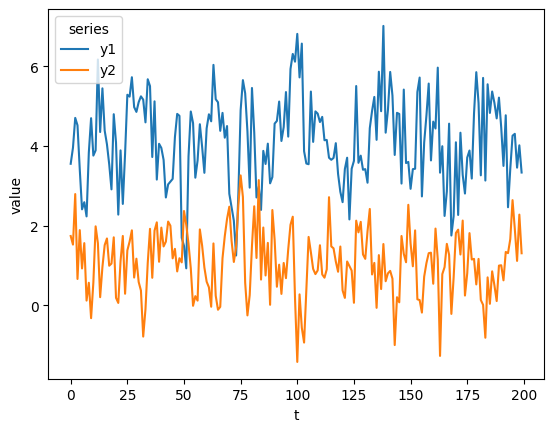

In [3]:
Y = sim_var_model(c, A_1, A_2, Sigma, T, seed=None)

df = pd.DataFrame(Y, columns=["y1", "y2"])
df["t"] = range(T)
df_long = df.melt(id_vars="t", var_name="series", value_name="value")

sns.lineplot(data=df_long, x="t", y="value", hue="series")

Plotting synthetic data.

In [4]:
from cmdstanpy import CmdStanModel, set_cmdstan_path
set_cmdstan_path("/deac/sta/classes/sta720/software/cmdstan/2.37.0")

stan_data = {
    "T": T,
    "K": len(c),
    "Y": Y
}

var_mod = CmdStanModel(stan_file="var_2.stan")
var_mod_post = var_mod.sample(data = stan_data)
print(var_mod_post.diagnose())
var_mod_params = var_mod_post.stan_variables()

19:36:02 - cmdstanpy - INFO - compiling stan file /deac/sta/classes/sta720-sp-2026/hatan25/720Bayes-Spring26/Thesis/var_2.stan to exe file /deac/sta/classes/sta720-sp-2026/hatan25/720Bayes-Spring26/Thesis/var_2
19:36:37 - cmdstanpy - INFO - compiled model executable: /deac/sta/classes/sta720-sp-2026/hatan25/720Bayes-Spring26/Thesis/var_2
19:36:37 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

19:37:36 - cmdstanpy - INFO - CmdStan done processing.
19:37:36 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: lkj_corr_lpdf: Correlation matrix is not positive definite. (in 'var_2.stan', line 22, column 4 to column 22)
	Exception: lkj_corr_lpdf: Correlation matrix is not positive definite. (in 'var_2.stan', line 22, column 4 to column 22)
	Exception: lkj_corr_lpdf: Correlation matrix is not positive definite. (in 'var_2.stan', line 22, column 4 to column 22)
	Exception: lkj_corr_lpdf: Correlation matrix is not positive definite. (in 'var_2.stan', line 22, column 4 to column 22)
	Exception: lkj_corr_lpdf: Correlation matrix is not positive definite. (in 'var_2.stan', line 22, column 4 to column 22)
	Exception: lkj_corr_lpdf: Correlation matrix is not positive definite. (in 'var_2.stan', line 22, column 4 to column 22)
	Exception: lkj_corr_lpdf: Correlation matrix is not positive definite. (in 'var_2.stan', line 22, column 4 to column 22)
	Exception: lkj_corr_lpdf:


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [5]:
print("True c:", c)
print("Estimated c:", var_mod_params["c"].mean(axis=0))

print("True A_1:", A_1)
print("Estimated A_1:", var_mod_params["A_1"].mean(axis=0))

print("True A_2:", A_2)
print("Estimated A_2:", var_mod_params["A_2"].mean(axis=0))

print(var_mod_post.summary())

True c: [2.5 1.5]
Estimated c: [2.3538173  1.45628738]
True A_1: [[ 0.45 -0.35]
 [-0.15  0.3 ]]
Estimated A_1: [[ 0.52405753 -0.2841841 ]
 [-0.10236187  0.30828157]]
True A_2: [[ 0.05 -0.05]
 [-0.05  0.03]]
Estimated A_2: [[-0.01845863  0.05164508]
 [-0.07160838 -0.07156053]]
                Mean      MCSE    StdDev       MAD          5%         50%  \
lp__     -124.957000  0.059747  2.620640  2.523990 -129.765000 -124.602000   
c[1]        2.353820  0.006622  0.344220  0.343556    1.778790    2.358150   
c[2]        1.456290  0.004445  0.239694  0.237839    1.067610    1.457900   
A_1[1,1]    0.524058  0.001541  0.075820  0.075309    0.399593    0.523457   
A_1[1,2]   -0.284184  0.001970  0.107360  0.110451   -0.457419   -0.286111   
A_1[2,1]   -0.102362  0.001136  0.055088  0.054400   -0.195195   -0.101952   
A_1[2,2]    0.308282  0.001486  0.076952  0.075850    0.177478    0.309254   
A_2[1,1]   -0.018459  0.001530  0.076756  0.075722   -0.145324   -0.018439   
A_2[1,2]    0.051645 

Everything looks like it ran correctly, posterior intervals capture our true values.

In [4]:
from cmdstanpy import CmdStanModel, set_cmdstan_path
set_cmdstan_path("/deac/sta/classes/sta720/software/cmdstan/2.37.0")

stan_data_hier = {
    "T": T,
    "K": len(c),
    "P": 2,
    "Y": Y
}

var_mod_hier = CmdStanModel(stan_file="var_2_hierarchical.stan")
var_mod_hier_post = var_mod_hier.sample(data = stan_data_hier)
print(var_mod_hier_post.diagnose())
var_mod_hier_params = var_mod_hier_post.stan_variables()

08:04:08 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

08:05:16 - cmdstanpy - INFO - CmdStan done processing.
08:05:16 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'var_2_hierarchical.stan', line 27, column 4 to column 26)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'var_2_hierarchical.stan', line 27, column 4 to column 26)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'var_2_hierarchical.stan', line 27, column 4 to column 26)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'var_2_hierarchical.stan', line 27, column 4 to column 26)
	Exception: lkj_corr_lpdf: Correlation matrix is not positive definite. (in 'var_2_hierarchical.stan', line 32, column 4 to column 22)
	Exception: lkj_corr_lpdf: Correlation matrix is not positive definite. (in 'var_2_hierarchical.stan', line 32, column 4 to column 22)
	Exception: lkj_corr_lpdf: Correlation matrix is n


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [7]:
print("True c:", c)
print("Estimated c:", var_mod_hier_params["c"].mean(axis=0))

print("True A_1:", A_1)
print("True A_2:", A_2)
print("Estimated A:", var_mod_hier_params["A"].mean(axis=0))

print(var_mod_hier_post.summary())

True c: [2.5 1.5]
Estimated c: [2.10302827 1.84243874]
True A_1: [[ 0.45 -0.35]
 [-0.15  0.3 ]]
True A_2: [[ 0.05 -0.05]
 [-0.05  0.03]]
Estimated A: [[[ 0.40497056 -0.08586854]
  [-0.22822889  0.30170722]]

 [[ 0.10924676 -0.00292225]
  [-0.03570613 -0.00538166]]]
                Mean      MCSE    StdDev       MAD          5%         50%  \
lp__     -137.278000  0.066370  2.780870  2.765980 -142.218000 -136.991000   
c[1]        2.103030  0.006878  0.352424  0.348456    1.537060    2.099470   
c[2]        1.842440  0.005547  0.276945  0.279475    1.382960    1.843310   
A[1,1,1]    0.404971  0.001286  0.069823  0.068444    0.288070    0.406519   
A[1,1,2]   -0.085869  0.001435  0.075897  0.075438   -0.215813   -0.082040   
A[1,2,1]   -0.228229  0.000899  0.049520  0.049153   -0.310917   -0.228215   
A[1,2,2]    0.301707  0.001223  0.071675  0.072134    0.184828    0.302038   
A[2,1,1]    0.109247  0.001359  0.069749  0.069020   -0.003434    0.108243   
A[2,1,2]   -0.002922  0.000833  